## Выполнение заданий лабораторной работы 10. Вариант 2_4.
## Выполнил: Ибраев Дамир Беркутбаевич

**Внимание!** Прежде, чем приступать к выполнению заданий, следует переименовать этот файл. В названии файла обязательно должна присутствовать фамилия студента – автора решения.

**За безымянные работы рейтинговые баллы начислены не будут!**

Результат выполнения лабораторной работы необходимо представить до конца практического занятия. Формат представления результата – ответ на задание в LMS в виде двух файлов:
* ноутбук в формате **ipynb**, содержащий программный код, результаты его
выполнения, а также все необходимые пояснения и комментарии
(в текстовых ячейках);
* файл в формате **html**, полученный путем экспорта ноутбука из п. 1.

Правильность работы представленного программного кода контролируется с помощью вопросов теста, ответы на которые также необходимо представить до конца практического занятия.

Критерии оценивания выполненной работы:
1. Наличие и качество решений практических заданий (ответов в текстовых ячейках, программного кода и комментариев к нему).   
   *  Ответы в текстовых ячейках на поставленные вопросы **обязательны для получения баллов** за проверочный тест.  
   *  Все выводимые на консоль значения должны быть **подписаны**.   
   *  Построенные графики должны быть хорошо читаемыми, иметь корректные названия и названия осей.   
    *  На графике с несколькими цветами **обязательна легенда** для идентификации каждого цвета.
2. Количество правильных ответов на вопросы проверочного теста.

**Внимание:** самостоятельное и вдумчивое выполнение заданий повышает вероятность успешного прохождения итогового теста по теме 10 на следующей учебной встрече (будет проверяться, в том числе, понимание принципов работы с инструментарием и, в частности, умение понимать программный код).

### Задание 1

Выполнить импорт библиотеки *NumPy* и модуля *Pyplot* библиотеки *Matplotlib*, а также подключить инструментарий для разбиения набора данных на обучающее/тестовое множество из библиотеки *Sciktit-learn*.

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

Остальной необходимый для работы инструментарий подключать в тех кодовых ячейках, где он впервые используется.

Комментарий: На данном этапе был подключён базовый инструментарий, необходимый для выполнения лабораторной работы: библиотеки для численных вычислений, визуализации и последующего разбиения данных на обучающую и тестовую выборки. Это сформировало техническую основу для дальнейшего анализа и построения модели.

### Задание 2

Сгенерировать модельный набор данных для задачи бинарной классификации по двум признакам, используя метод *make_classification*. При генерации задать:
*   общее количество объектов равным 230,
*   все признаки являются информативными,
*   нет линейно-зависимых признаков,
*   по одному облаку точек на каждый класс,
*   коэффициент, определяющий степень разделимости классов (*class_sep*), равный 1,
*   *random_state* равный 48.

In [55]:
X, y = make_classification(
    n_samples=230,      
    n_features=2,         
    n_informative=2,     
    n_redundant=0,       
    n_repeated=0,       
    n_classes=2,        
    n_clusters_per_class=1, 
    class_sep=1,          
    random_state=48
)

print("Размер X:", X.shape)
print("Размер y:", y.shape)
print("Первые 5 объектов:\n", X[:5])
print("Первые 5 меток:\n", y[:5])

Размер X: (230, 2)
Размер y: (230,)
Первые 5 объектов:
 [[-1.36091158  1.67792378]
 [ 0.322488    1.93036789]
 [-0.86973928  0.34678566]
 [-0.09335314  2.74141372]
 [ 0.92993947  0.5444409 ]]
Первые 5 меток:
 [0 1 0 1 1]


Вывести сгенерированные значения признаков и метку класса для первых 12 объектов. Значения признаков округлить до 3 знаков после запятой.

In [56]:
df_first_12 = pd.DataFrame(X[:12], columns=['Признак 1', 'Признак 2'])
df_first_12['Метка класса'] = y[:12]

print(df_first_12.round(3))

    Признак 1  Признак 2  Метка класса
0      -1.361      1.678             0
1       0.322      1.930             1
2      -0.870      0.347             0
3      -0.093      2.741             1
4       0.930      0.544             1
5      -0.929      0.710             0
6       0.786      1.882             1
7      -1.261      1.412             0
8       0.219      0.561             1
9       0.161      1.556             1
10     -0.945      1.608             1
11      0.910      0.991             1


Проверить сбалансированность классов в сгенерированном наборе, вычислив доли объектов, относящихся к каждому из классов.

In [57]:
class_counts = pd.Series(y).value_counts().sort_index()
class_shares = pd.Series(y).value_counts(normalize=True).sort_index()

print("Количество объектов по классам:")
print(class_counts)

print("\nДоли объектов по классам:")
print(class_shares)

Количество объектов по классам:
0    115
1    115
Name: count, dtype: int64

Доли объектов по классам:
0    0.5
1    0.5
Name: proportion, dtype: float64


Ответить на вопрос: является ли задача бинарной классификации сбалансированной или наблюдается дисбаланс классов?

__*Ваш ответ:*__ Задача является сбалансированной т.к.

* класс 0: 115 объектов, доля 0.5
* класс 1: 115 объектов, доля 0.5

Выполнить визуализацию сгенерированного набора данных в виде диаграммы рассеяния, изобразив объекты, относящиеся к разным классам, разными цветами.

**Указание**. Визуализация должна содержать легенду с отображением соответствия цветов и меток классов. Выбор цветов можно оставить «по умолчанию» или же настроить свой, используя *ListedColormap*.

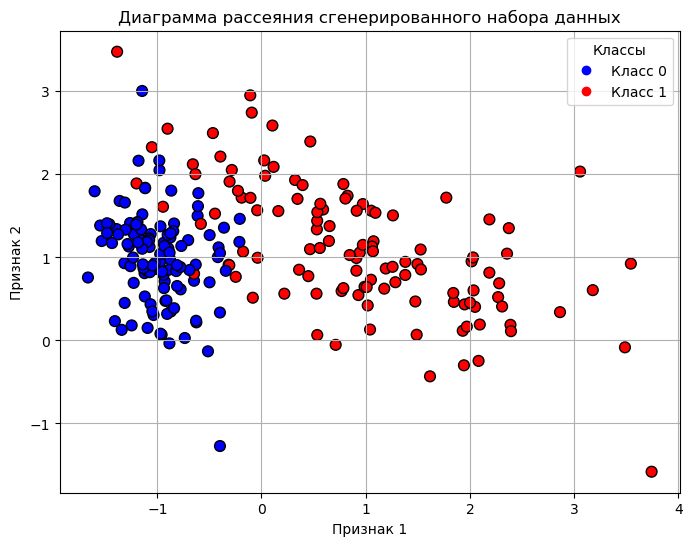

In [58]:
from matplotlib.colors import ListedColormap

cmap = ListedColormap(['blue', 'red'])

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, edgecolors='k', s=60)

plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('Диаграмма рассеяния сгенерированного набора данных')
plt.grid(True)

handles, _ = scatter.legend_elements()
plt.legend(handles, ['Класс 0', 'Класс 1'], title='Классы')

plt.show()

По результатам визуализации ответить на вопросы:

* в каких областях пространства модель логистической регрессии будет предсказывать вероятность, близкую к 1? к 0?

*  где будут находиться объекты, которым модель логистической регрессии будет предсказывать вероятность около 0.5?

* как будет выглядеть разделяющая классы граница при использовании модели логистической регрессии?


__*Ваши ответы:*__

* Вероятность, близкую к 1, модель логистической регрессии будет предсказывать в тех областях пространства признаков, где сосредоточены объекты класса 1. Вероятность, близкую к 0, — в областях, где сосредоточены объекты класса 0.
* Вероятность около 0.5 будет у объектов, находящихся вблизи границы разделения классов, то есть в переходной зоне между двумя облаками точек.
* Разделяющая граница в логистической регрессии будет иметь вид прямой линии, потому что модель строит линейную границу в пространстве двух признаков.


Комментарий: На данном этапе был сгенерирован модельный набор данных для задачи бинарной классификации с двумя информативными признаками. Полученный набор данных является удобной основой для исследования поведения модели логистической регрессии и анализа качества классификации.

### Задание 3

Выполнить разбиение сгенерированного набора данных на обучающую и тестовую выборки в соотношении 80/20. При разбиении задать *random_state* = 48.

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=48
)

Вывести для ознакомления информацию о полученных выборках:
*   определить количество объектов в обучающей и тестовой выборках;
*   проверить баланс классов в обучающей и тестовой выборках, определив доли каждого класса. Полученные значения округлить до 3 знаков после запятой.



In [60]:
print("Количество объектов в обучающей выборке:", len(X_train))
print("Количество объектов в тестовой выборке:", len(X_test))

Количество объектов в обучающей выборке: 184
Количество объектов в тестовой выборке: 46


In [61]:
train_shares = pd.Series(y_train).value_counts(normalize=True).sort_index().round(3)
test_shares = pd.Series(y_test).value_counts(normalize=True).sort_index().round(3)

print("Доли классов в обучающей выборке:")
print(train_shares)

print("\nДоли классов в тестовой выборке:")
print(test_shares)

Доли классов в обучающей выборке:
0    0.511
1    0.489
Name: proportion, dtype: float64

Доли классов в тестовой выборке:
0    0.457
1    0.543
Name: proportion, dtype: float64


Ответить на вопрос: получившееся соотношение классов в обучающей и тестовой выборке близко к исходному соотношению классов в сгенерированном наборе данных или нет?

__*Ваш ответ:*__ Получившееся соотношение классов в обучающей и тестовой выборках в целом близко к исходному, но не полностью совпадает с ним. В исходном наборе классы были распределены строго поровну 50/50, а после разбиения возникло небольшое отклонение. Это нормальная ситуация, потому что разбиение выполнено без stratify.



**Замечание**. В общем случае перед обучением логистической регрессии  требуется провести масштабирование числовых признаков. Однако в данных, сгенерированных таким образом с помощью *make_classification*, признаки уже имеют сопоставимые масштабы и близкие характеристики разброса, поэтому в данном случае масштабирование не требуется.

Комментарий: На данном этапе исходный набор данных был разделён на обучающую и тестовую выборки в соотношении 80/20. Такое разбиение позволило отдельно обучить модель и затем объективно оценить её качество на новых данных.

### Задание 4

Импортировать инструментарий, необходимый для построения модели логистической регрессии. Создать модель с $L_2$-регуляризацией и коэффициентом регуляризации $\lambda = 0.125$.

In [62]:
model = LogisticRegression(
    penalty='l2',  
    C=8,           
    random_state=48
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,8
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,48
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Получить коэффициенты обученной модели. Вывести полученные значения, округлив их до 2 знаков после запятой.

**Указание**. Не забыть про свободный коэффициент модели.

In [63]:
print("Коэффициенты:", np.round(model.coef_[0], 2))
print("Свободный коэффициент:", round(model.intercept_[0], 2))

Коэффициенты: [5.25 2.89]
Свободный коэффициент: -1.61


Записать уравнение обученной модели логистической регрессии в формате $\pi(x) = \dfrac {1}{1+e^{- \left ( w_0 + w_1 \cdot x^1 + w_2 \cdot x^2 \right )}}$.

__*Ваш ответ:*__ π(x) = 1 / (1 + e^-(-1.61 + 5.25·x1 + 2.89·x2))

Ответить на вопросы:

*  что предсказывает модель логистической регресии?

*  какое предсказание будет получено при больших положительных значениях $w_0 + w_1 \cdot x^1 + w_2 \cdot x^2$? При больших отрицательных? При близких к 0?

*  как знак коэффициента влияет на предсказание модели?

__*Ваши ответы:*__

* Модель логистической регрессии предсказывает вероятность принадлежности объекта к классу 1.
* Если значение z = b + w1·x1 + w2·x2: большое положительное -> π(x) -> 1 (класс 1); большое отрицательное -> π(x) -> 0 (класс 0); близко к 0 → π(x) ≈ 0.5 (граница классов).
* Знак коэффициента: положительный → рост признака увеличивает вероятность класса 1, отрицательный → рост признака уменьшает вероятность класса 1.

Вывести объект обучающей выборки с индексом 71, округлив значения значения признаков до 2 знаков после запятой.

In [64]:
x1 = round(X_train[71][0], 2)
x2 = round(X_train[71][1], 2)

print(f"x1 = {x1}, x2 = {x2}")
print("Истинный класс:", y_train[71])

x1 = -0.98, x2 = 2.16
Истинный класс: 0


Используя записанную формулу обученной модели логистической регрессии определить проноз модели для данного объекта «вручную» (без использования кода).

**Указание**. Должен быть записан не только финальный ответ, но и промежуточные вычисления.


__*Ваш ответ:*__

x1 = -0.98, x2 = 2.16

z = -1.61 + 5.25·x1 + 2.89·x2

z = -1.61 + 5.25·(-0.98) + 2.89·2.16

z = -1.61 - 5.145 + 6.2424

z = -0.5126 ≈ -0.51

π(x) = 1 / (1 + e^{-z})

π(x) = 1 / (1 + e^{0.5126})

e^{0.5126} ≈ 1.67

π(x) ≈ 1 / (1 + 1.67) ≈ 0.374

Ответ:

π(x) ≈ 0.374

Так как π(x) < 0.5, модель предсказывает класс 0.

Записать правило прогнозирования метки класса объекта для значения порога вероятности 0,5.

__*Ваш ответ:*__

Если π(x) ≥ 0.5, то объект относится к классу 1.

Если π(x) < 0.5, то объект относится к классу 0.

Используя записанное правило прогнозирования метки класса и получить прогнозируемую метку класса для объекта с индексом 71 «вручную» (без использования кода).

**Указание**. Должен быть записан не только финальный ответ, но и промежуточные вычисления.

__*Ваш ответ:*__

x1 = -0.98, x2 = 2.16

z = -1.61 + 5.25·x1 + 2.89·x2

z = -1.61 + 5.25·(-0.98) + 2.89·2.16

z = -1.61 - 5.145 + 6.2424

z = -0.5126 ≈ -0.51

Правило:

если z ≥ 0 → класс 1

если z < 0 → класс 0

Так как z = -0.51 < 0, то прогнозируемый класс = 0.

Какую прогнозируемую метку класса получил бы данный объект, если бы в правиле  прогнозирования метки класса использовался порог 0,35?

__*Ваш ответ:*__

Ранее получено:

π(x) ≈ 0.374

Новое правило:

если π(x) ≥ 0.35 → класс 1

если π(x) < 0.35 → класс 0

Сравниваем:

0.374 ≥ 0.35

Следовательно, прогнозируемый класс = 1.

**Вопрос 6 в тесте**

Какую прогнозируемую метку класса получит объект обучающей выборки с индексом 71 при значении пороговой вероятности 0,35?

Для обучающей выборки получить предсказания обученной модели и пронозируемые метки классов.

In [65]:
y_pred = model.predict(X_train)
y_proba = model.predict_proba(X_train)

Вывести обученной модели и пронозируемые метки классов для первых 12 объектов обучающей выборки. Значения вероятностей округлить до 3 знаков после запятой.

In [66]:
for i in range(12):
    p = np.round(y_proba[i], 3)
    print(f"Объект {i}: вероятности = {p}, предсказанный класс = {y_pred[i]}")

Объект 0: вероятности = [0.002 0.998], предсказанный класс = 1
Объект 1: вероятности = [1. 0.], предсказанный класс = 0
Объект 2: вероятности = [0.959 0.041], предсказанный класс = 0
Объект 3: вероятности = [0.048 0.952], предсказанный класс = 1
Объект 4: вероятности = [0.006 0.994], предсказанный класс = 1
Объект 5: вероятности = [0.255 0.745], предсказанный класс = 1
Объект 6: вероятности = [0.999 0.001], предсказанный класс = 0
Объект 7: вероятности = [0.988 0.012], предсказанный класс = 0
Объект 8: вероятности = [0. 1.], предсказанный класс = 1
Объект 9: вероятности = [0.014 0.986], предсказанный класс = 1
Объект 10: вероятности = [0.996 0.004], предсказанный класс = 0
Объект 11: вероятности = [0. 1.], предсказанный класс = 1


Дать оценку уверенности модели в принадлежности объекта к прогнозируемому классу для данных объектов.

__*Ваш ответ:*__

Модель демонстрирует различную степень уверенности в предсказаниях. 

Для объектов, удалённых от границы разделения, вероятности близки к 0 или 1, что свидетельствует о высокой уверенности модели.

Для объектов, расположенных вблизи границы, вероятности близки к 0.5, что указывает на низкую уверенность и неопределённость классификации.


Комментарий: На данном этапе была построена и обучена модель логистической регрессии с L2-регуляризацией. Использование регуляризации позволило ограничить избыточный рост коэффициентов модели и повысить устойчивость классификации.

### Задание 5

Вычислить долю правильных ответов, точность, полноту и *F*-меру на обучающей выборке. Вывести полученные значения, округлив их до 3 знаков после запятой.

In [67]:
y_train_pred = model.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

print("Обучающая выборка:")
print("Accuracy =", round(train_accuracy, 3))
print("Precision =", round(train_precision, 3))
print("Recall =", round(train_recall, 3))
print("F1 =", round(train_f1, 3))

Обучающая выборка:
Accuracy = 0.951
Precision = 0.966
Recall = 0.933
F1 = 0.949


Вычислить долю правильных ответов, точность, полноту и *F*-меру на тестовой выборке. Вывести полученные значения, округлив их до 3 знаков после запятой.

In [68]:
y_test_pred = model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("Тестовая выборка:")
print("Accuracy =", round(test_accuracy, 3))
print("Precision =", round(test_precision, 3))
print("Recall =", round(test_recall, 3))
print("F1 =", round(test_f1, 3))

Тестовая выборка:
Accuracy = 0.891
Precision = 0.917
Recall = 0.88
F1 = 0.898


Дать интерпретацию полученным значениям метрик на тестовой выборке (с пояснением того, какую величину измеряет каждая метрика).

__*Ваши ответы:*__

* Accuracy показывает долю всех объектов, для которых модель определила класс верно. На тестовой выборке accuracy = 0.891, то есть модель правильно классифицировала около 89.1% объектов.
* Precision показывает, какая доля объектов, отнесённых моделью к классу 1, действительно принадлежит классу 1. На тестовой выборке precision = 0.917, значит среди объектов, предсказанных как класс 1, около 91.7% оказались верными.
* Recall показывает, какую долю всех реальных объектов класса 1 модель смогла обнаружить. На тестовой выборке recall = 0.880, то есть модель нашла около 88.0% всех объектов положительного класса.
* F1-мера является гармоническим средним между precision и recall и характеризует общий баланс между точностью и полнотой. На тестовой выборке F1 = 0.898, что указывает на хороший сбалансированный результат классификации.  

Дать оценку качества классификации.

__*Ваш ответ:*__ Модель демонстрирует высокое качество классификации. Все ключевые метрики на тестовой выборке близки к 0.9, что говорит о хорошем уровне обобщающей способности. При этом значения метрик на тестовой выборке немного ниже, чем на обучающей, но разрыв невелик, поэтому выраженного переобучения не наблюдается.

Комментраий: На данном этапе были проанализированы коэффициенты обученной модели и записано её аналитическое уравнение. Это позволило интерпретировать влияние признаков на вероятность принадлежности объекта к положительному классу и вручную проследить механизм формирования прогноза

### Задание 6

Для порога вероятности, равного 0,35, получить и визуализировать матрицу ошибок на тестовой выборке.

**Указание**. Сначала нужно получить прогнозируемые метки классов для объектов тестовой выборки, реализовав правило правило прогнозирования для указанного порога.

Матрица ошибок:
[[18  3]
 [ 1 24]]


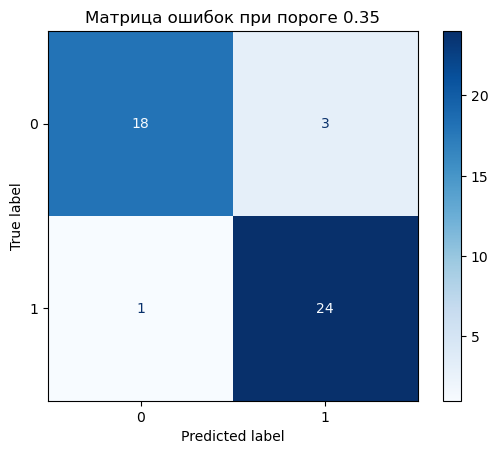

In [69]:
y_test_proba = model.predict_proba(X_test)[:, 1]
y_test_pred_035 = (y_test_proba >= 0.35).astype(int)

cm = confusion_matrix(y_test, y_test_pred_035)

print("Матрица ошибок:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title('Матрица ошибок при пороге 0.35')
plt.show()

Используя построенную матрицу ошибок, вычислить значения $FPR$ и $TPR$ «вручную» (без использования кода).

**Указание**. Должен быть записан не только финальный ответ, но и промежуточные вычисления.


__*Ваш ответ:*__

По матрице ошибок:

TN = 18, FP = 3, FN = 1, TP = 24

FPR = FP / (FP + TN)

FPR = 3 / (3 + 18)

FPR = 3 / 21

FPR = 0.143


TPR = TP / (TP + FN)

TPR = 24 / (24 + 1)

TPR = 24 / 25

TPR = 0.960

**Вопрос 10 в тесте**

Чему равна доля истинных срабатываний алгоритма на тестовой выборке при пороге вероятности, равном 0,635?

Ввести значение с точностью до 3 знаков после запятой.

Получить значения $FPR$ и $TPR$, а также значения порогов вероятности, использованных для их рассчета, на обучающей и тестовой выборках отдельно.

In [70]:
y_train_proba = model.predict_proba(X_train)[:, 1]
y_test_proba = model.predict_proba(X_test)[:, 1]

fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_proba)

Вывести полученные значения порогов, $FPR$ и $TPR$ на тестовой выборке.

In [71]:
roc_test_df = pd.DataFrame({
    'threshold': thresholds_test,
    'FPR': fpr_test,
    'TPR': tpr_test
})

print(roc_test_df.round(3))

    threshold    FPR   TPR
0         inf  0.000  0.00
1       1.000  0.000  0.04
2       0.910  0.000  0.76
3       0.822  0.048  0.76
4       0.763  0.048  0.84
5       0.743  0.095  0.84
6       0.701  0.095  0.88
7       0.466  0.143  0.88
8       0.353  0.143  0.96
9       0.175  0.190  0.96
10      0.128  0.190  1.00
11      0.001  1.000  1.00


Построить $ROC$-кривые для обучающей и тестовой выборках (на одном графике).

**Указание**. Не забыть про легенду.

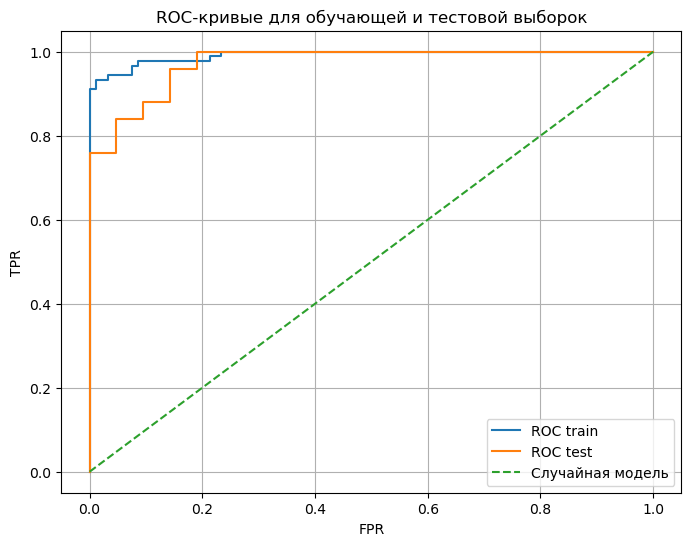

In [72]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label='ROC train')
plt.plot(fpr_test, tpr_test, label='ROC test')
plt.plot([0, 1], [0, 1], linestyle='--', label='Случайная модель')

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC-кривые для обучающей и тестовой выборок')
plt.grid(True)
plt.legend()
plt.show()

Оценить качество прогноза вероятности принадлежности классу по полученным кривым.

__*Ваш ответ:*__ ROC-кривые для обучающей и тестовой выборок проходят близко к левому верхнему углу,
что свидетельствует о высоком качестве прогноза вероятности принадлежности к классу.

Кривая на обучающей выборке расположена немного выше, чем на тестовой,
однако различие невелико. Это означает, что модель хорошо обобщает данные,
а выраженного переобучения не наблюдается.



 Найти значения метрики $AUC-ROC$ на обучающей и тестовой выборках. Вывести полученные значения, округлив их до 3 знаков после запятой.

In [73]:
auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

print("AUC-ROC на обучающей выборке =", round(auc_train, 3))
print("AUC-ROC на тестовой выборке =", round(auc_test, 3))

AUC-ROC на обучающей выборке = 0.992
AUC-ROC на тестовой выборке = 0.973


Дать интерпретацию полученным значениям метрики (с пояснением того, какую величину измеряет метрика). Оценить качество прогноза вероятности принадлежности классу по полученным значениям метрики.

__*Ваш ответ:*__ Метрика AUC-ROC измеряет качество ранжирования объектов моделью
и показывает, насколько хорошо модель отделяет объекты класса 1 от объектов класса 0.
Чем ближе значение AUC-ROC к 1, тем лучше модель различает классы.

На обучающей выборке AUC-ROC = 0.992, на тестовой выборке AUC-ROC = 0.973.
Оба значения очень близки к 1, следовательно, модель демонстрирует очень высокое качество
прогноза вероятности принадлежности к классу.

Так как значение на тестовой выборке также остается очень высоким,
можно сделать вывод, что модель хорошо работает не только на обучающих данных,
но и на новых объектах.


Комментарий: На данном этапе была исследована матрица ошибок при изменённом пороге вероятности, а также проанализированы показатели TPR и FPR. Это позволило оценить, как выбор порога влияет на качество классификации и характер ошибок модели. Также были исследованы ROC-кривые и рассчитана метрика AUC-ROC для обучающей и тестовой выборок. Полученные результаты позволили оценить качество вероятностного прогноза модели и сделать вывод о её способности различать объекты двух классов.